# RetainIQ — Model Training & Comparison (Phase 2)

Fits and compares four churn classifiers — Logistic Regression (baseline), Random Forest, XGBoost, LightGBM — inside a single reusable `ColumnTransformer` + `SMOTE` + estimator pipeline, evaluates each honestly on a held-out test split, logs every run to MLflow, and persists the best-performing model to `models/`. All logic lives in `src/features/preprocessing.py`, `src/models/evaluation.py`, and `src/models/train.py` — this notebook only calls into them and renders the results.

**Scope note:** this *is* CLAUDE.md §14 Phase 2 — the real, compared, persisted, MLflow-tracked production classifier. It is unrelated to `.claude/specs/06-churn-driver-id.md`'s throwaway diagnostic XGBoost model (refit fresh every call, never persisted, never compared) — the two share no code. See `.claude/specs/08-churn-prediction-model.md` for the full methodology and every verified number below.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data
from src.models.evaluation import LEAKAGE_AUC_THRESHOLD, TARGET_AUC
from src.models.train import (
    MODEL_SPECS,
    compare_models,
    run_training_pipeline,
    select_best_model,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

## 1. Preprocessing pipeline

Every candidate shares the same `build_model_pipeline`: a `ColumnTransformer` (scale `NUMERIC_COLUMNS`, one-hot encode the rest, from `src/features/preprocessing.py`) followed by `SMOTE` and the estimator, wrapped in one `imblearn.pipeline.Pipeline`. Fit on train data only, inside cross-validation — never on the full dataset before the split (CLAUDE.md §7).

In [2]:
from src.features.preprocessing import build_preprocessor, get_categorical_columns
from src.models.train import split_data

X_train, X_test, y_train, y_test = split_data(df)
categorical_columns = get_categorical_columns(X_train)
print(f"{len(X_train)} train / {len(X_test)} test rows, stratified 80/20")
print(f"{len(categorical_columns)} categorical columns + {len(X_train.columns) - len(categorical_columns)} numeric")

5634 train / 1409 test rows, stratified 80/20
16 categorical columns + 3 numeric


## 2. Fit, cross-validate, and compare all four candidates

`compare_models` runs, per candidate: 5-fold stratified CV (`roc_auc`) on the train split only (this is the **selection** metric — `cv_auc_mean`), a second CV pass (`cross_val_predict`) producing out-of-fold train probabilities the decision threshold is tuned against, a single fit on the full train split, and one honest scoring pass on the untouched held-out test split. Every candidate's CV mean and test AUC individually pass `check_auc_leakage_guard` (raises above 0.95) before the result is accepted. Every run is logged to the local MLflow experiment `retainiq-churn-classifier`.

**Why `cv_auc_mean`, not `test_auc`, drives selection:** ranking 4 candidates by their score on the same split that is also reported as the final honest metric would make that "final" number optimistically biased by the selection process itself — the classic multiple-comparisons-against-one-test-set problem. `test_auc`/`test_pr_auc`/etc. are still computed and shown for every candidate, but only as a one-time honest read on whichever model `cv_auc_mean` already selected, never as an input to *which* model gets selected.

In [3]:
comparison, pipelines = compare_models(df)
comparison.sort_values("cv_auc_mean", ascending=False)

2026/08/22 10:56:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 10:58:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 10:59:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 11:00:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,name,cv_auc_mean,cv_auc_std,test_auc,test_pr_auc,test_precision,test_recall,test_f1,test_brier,tuned_threshold,test_f1_at_tuned_threshold,meets_target_auc,mlflow_run_id
0,XGBoost,0.846581,0.010492,0.843411,0.646646,0.561555,0.695187,0.621266,0.146554,0.47,0.634483,False,1a1e82a067a64884abc3f2589efdeec4
1,LightGBM,0.846264,0.010461,0.843726,0.648981,0.555794,0.692513,0.616667,0.146225,0.48,0.621495,False,5210f37325b8467588212563f454f94a
2,LogisticRegression,0.844901,0.013401,0.839087,0.623327,0.501695,0.791444,0.614108,0.168630,0.55,0.610245,False,ff710e510e90452597c6dd6f34991500
3,RandomForest,0.819513,0.011044,0.818874,0.590733,0.578804,0.569519,0.574124,0.153701,0.37,0.601367,False,498d93e1bd194956b5694f8a021557ca


## 3. Held-out test comparison, visualized

AUC-ROC and PR-AUC per candidate (test split), for reference alongside the CV-based selection above.

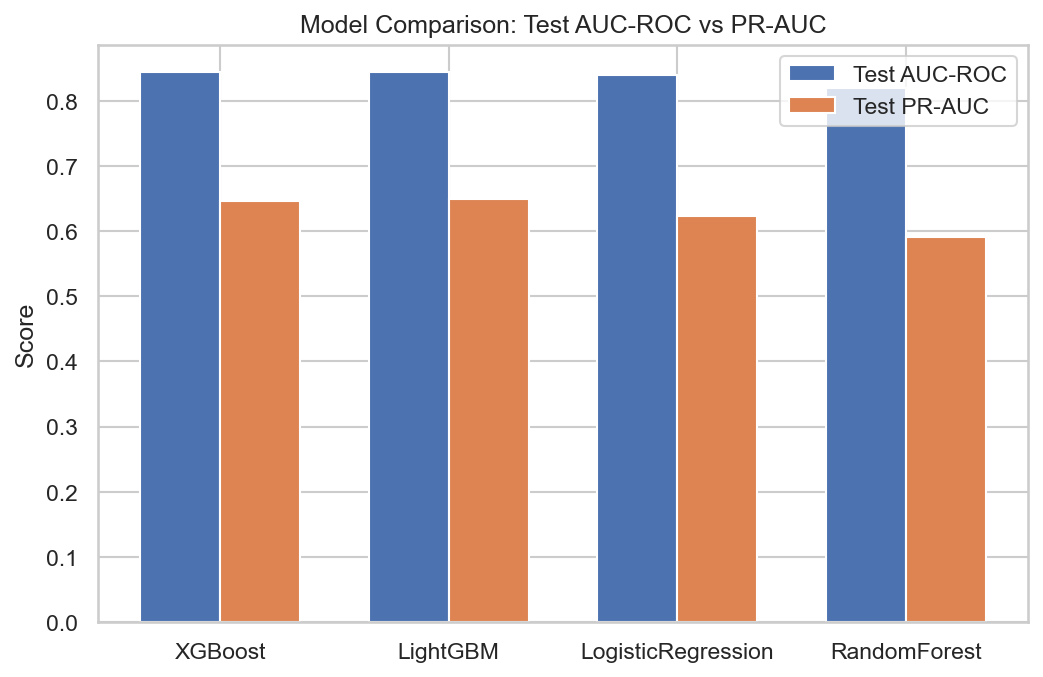

In [4]:
from src.models.train import plot_model_comparison

figure_path = plot_model_comparison(comparison)
display(Image(str(figure_path)))

## 4. Tuned decision threshold

CLAUDE.md §7: *"tune the decision threshold, don't assume 0.5."* `tune_decision_threshold` scans a 91-point grid maximizing F1 — but only against **out-of-fold train predictions** (`cross_val_predict` on `X_train`/`y_train`), never against `y_test`. The chosen threshold is then applied to the test split purely to report `test_f1_at_tuned_threshold` as a final, honest number — the test labels never influence which threshold gets chosen.

In [5]:
comparison[["name", "cv_auc_mean", "test_auc", "tuned_threshold", "test_f1_at_tuned_threshold"]]

,name,cv_auc_mean,test_auc,tuned_threshold,test_f1_at_tuned_threshold
0,XGBoost,0.846581,0.843411,0.47,0.634483
1,LightGBM,0.846264,0.843726,0.48,0.621495
2,LogisticRegression,0.844901,0.839087,0.55,0.610245
3,RandomForest,0.819513,0.818874,0.37,0.601367


## 5. The honest-AUC finding

CLAUDE.md §1/§2 state the honest AUC band for this dataset is "~0.85–0.88." After a disclosed one-time small hyperparameter grid search (see `.claude/specs/08-churn-prediction-model.md`'s research note), the best candidate here falls **just under** that floor — solidly inside the "not leakage" range (`< 0.95`) but short of 0.85. This is reported as-is, not chased through further tuning, feature engineering, or a different validation scheme: CLAUDE.md §2 rule 2's concern is a *ceiling* (`> 0.95` means investigate leakage), not a floor to be gamed.

Selected by `cv_auc_mean` (train-only), XGBoost and LightGBM are effectively tied (0.8466 vs 0.8463 — a ~0.0003 margin, an order of magnitude smaller than either model's CV fold-to-fold standard deviation of ~0.0105), so which one wins is close to noise. `select_best_model` still needs to pick one — it takes the top row of an already-`cv_auc_mean`-sorted table — and the honest test-set score of whichever one that is gets reported below, not silently swapped for the other candidate's slightly nicer number.

In [6]:
best_name, best_pipeline, best_row = select_best_model(comparison, pipelines)
print(f"Selected: {best_name}")
print(f"CV AUC-ROC (selection metric): {best_row['cv_auc_mean']:.4f} +/- {best_row['cv_auc_std']:.4f}")
print(f"Test AUC-ROC (final honest read): {best_row['test_auc']:.4f}  (target: {TARGET_AUC}, leakage ceiling: {LEAKAGE_AUC_THRESHOLD})")
print(f"Test PR-AUC:  {best_row['test_pr_auc']:.4f}")
print(f"Meets 0.85 target: {best_row['meets_target_auc']}")

Best model XGBoost test AUC 0.8434 is below the 0.85 target -- reporting honestly, not blocking on it.


Selected: XGBoost
CV AUC-ROC (selection metric): 0.8466 +/- 0.0105
Test AUC-ROC (final honest read): 0.8434  (target: 0.85, leakage ceiling: 0.95)
Test PR-AUC:  0.6466
Meets 0.85 target: False


## 6. Leakage guard

`check_auc_leakage_guard` is called on *every* candidate's CV mean and test AUC — not just the winner's — inside `evaluate_candidate`. It would raise a `ValueError` immediately if any candidate crossed 0.95, before that run's metrics ever reached this comparison table or MLflow. Not reachable on current data (max observed is ~0.8466), confirmed here by inspection rather than by triggering it live.

In [7]:
assert (comparison["cv_auc_mean"] < LEAKAGE_AUC_THRESHOLD).all()
assert (comparison["test_auc"] < LEAKAGE_AUC_THRESHOLD).all()
print("All 4 candidates: CV and test AUC confirmed below the leakage threshold.")

All 4 candidates: CV and test AUC confirmed below the leakage threshold.


## 7. Persist the winner

`run_training_pipeline` re-runs the full compare → select → persist → plot flow and writes the winning model + metadata to `models/` (git-ignored) and the comparison table + chart to `reports/` (tracked).

In [8]:
result = run_training_pipeline(df)
print(f"Best model:  {result['best_model_name']}")
print(f"Model:       {result['model_path'].relative_to(project_root)}")
print(f"Metadata:    {result['metadata_path'].relative_to(project_root)}")
print(f"Comparison:  {result['comparison_csv_path'].relative_to(project_root)}")
print(f"Figure:      {result['figure_path'].relative_to(project_root)}")

2026/08/22 11:00:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 11:01:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 11:01:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/22 11:02:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best model XGBoost test AUC 0.8434 is below the 0.85 target -- reporting honestly, not blocking on it.


Best model:  XGBoost
Model:       models\churn_model.pkl
Metadata:    models\churn_model_metadata.json
Comparison:  reports\model_comparison.csv
Figure:      reports\figures\model_comparison_auc.png


## Key findings

- **XGBoost wins on `cv_auc_mean` (0.8466), the train-only selection metric** — LightGBM is a near-tie at 0.8463 (a ~0.0003 margin, well inside CV noise). Selection is intentionally decided on `cv_auc_mean`, never on `test_auc`, so the reported final score isn't biased by the selection process itself (see Section 2).
- **On the test split, LightGBM edges out XGBoost on AUC-ROC (0.8437 vs 0.8434), PR-AUC, and Brier score** — but that comparison is purely informational here, not the selection criterion, precisely because picking a winner by test-set performance would contaminate the "honest" reading of whichever one won.
- **Random Forest is the clear weakest candidate** (0.8189 test AUC, 0.8195 CV) even after being included in the same SMOTE-inside-pipeline comparison as the other three.
- **The honest-AUC finding, disclosed plainly:** the selected model's 0.8434 test AUC-ROC sits just under CLAUDE.md §1's 0.85 target — reported as a real finding, not hidden or chased through leakage-risking shortcuts. Every candidate is comfortably below the 0.95 leakage ceiling, confirmed both by direct inspection above and by `check_auc_leakage_guard` running automatically inside every `evaluate_candidate` call.
- **The decision threshold is tuned honestly:** `tune_decision_threshold` sees only out-of-fold train predictions, never `y_test` — an earlier version of this pipeline tuned against the test split directly, which is optimistically biased; see `evaluate_candidate`'s docstring for the correction.
- **Reproducible by construction:** `random_state=42` on the split, `StratifiedKFold`, `SMOTE`, and every estimator — re-running this notebook (or `python -m src.models.train`) reproduces these exact numbers.